In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/online_retail.csv/cleaned_retail.csv")

In [6]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [8]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [20]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

In [21]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [22]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [24]:
rfm.shape

(5878, 3)

In [27]:
rfm.describe

<bound method NDFrame.describe of              Recency  Frequency  Monetary
Customer ID                              
12346.0          326         12  77556.46
12347.0            2          8   5633.32
12348.0           75          5   2019.40
12349.0           19          4   4428.69
12350.0          310          1    334.40
...              ...        ...       ...
18283.0            4         22   2736.65
18284.0          432          1    461.68
18285.0          661          1    427.00
18286.0          477          2   1296.43
18287.0           43          7   4182.99

[5878 rows x 3 columns]>

In [28]:
rfm[rfm['Recency']==0]

,Recency,Frequency,Monetary
Customer ID,,,


In [29]:
rfm[rfm['Recency']==1]

,Recency,Frequency,Monetary
Customer ID,,,
12423.0,1,10,2622.39
12433.0,1,10,20581.26
12518.0,1,5,2056.89
12526.0,1,3,1316.66
12662.0,1,20,6988.02
...,...,...,...
17675.0,1,70,38259.60
17754.0,1,13,4577.53
17757.0,1,56,9422.45


In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [31]:
import matplotlib.pyplot as plt 

Text(0, 0.5, 'Customers')

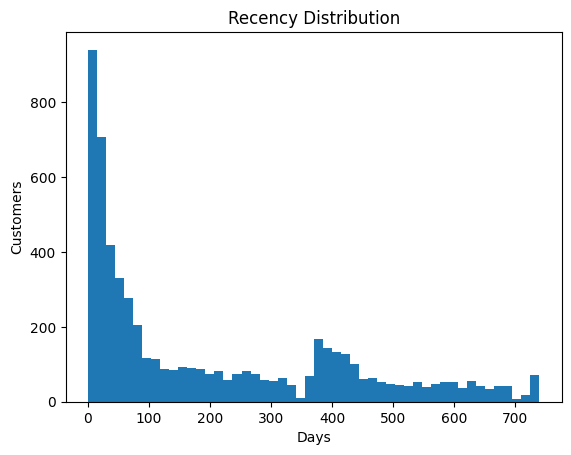

In [33]:
plt.hist(rfm['Recency'],bins=50)
plt.title("Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

Text(0, 0.5, 'Customers')

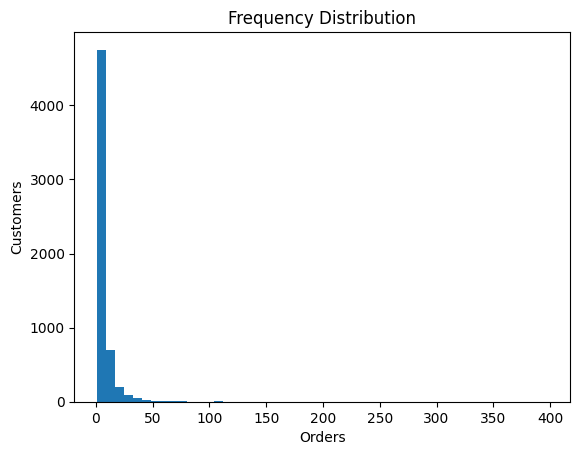

In [34]:
plt.hist(rfm['Frequency'],bins=50)
plt.title('Frequency Distribution')
plt.xlabel('Orders')
plt.ylabel('Customers')

Text(0, 0.5, 'Customers')

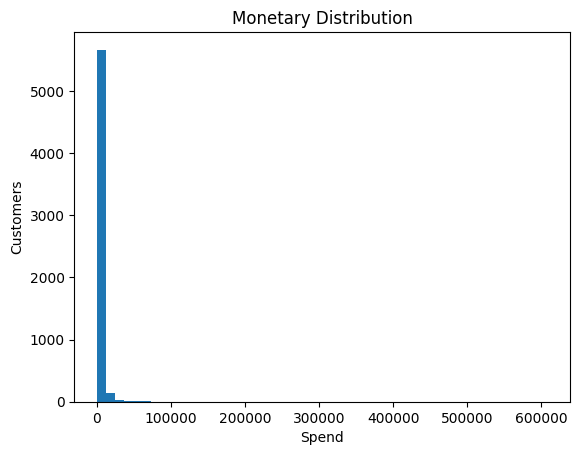

In [36]:
plt.hist(rfm['Monetary'],bins=50)
plt.title('Monetary Distribution')
plt.xlabel('Spend')
plt.ylabel('Customers')

In [37]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

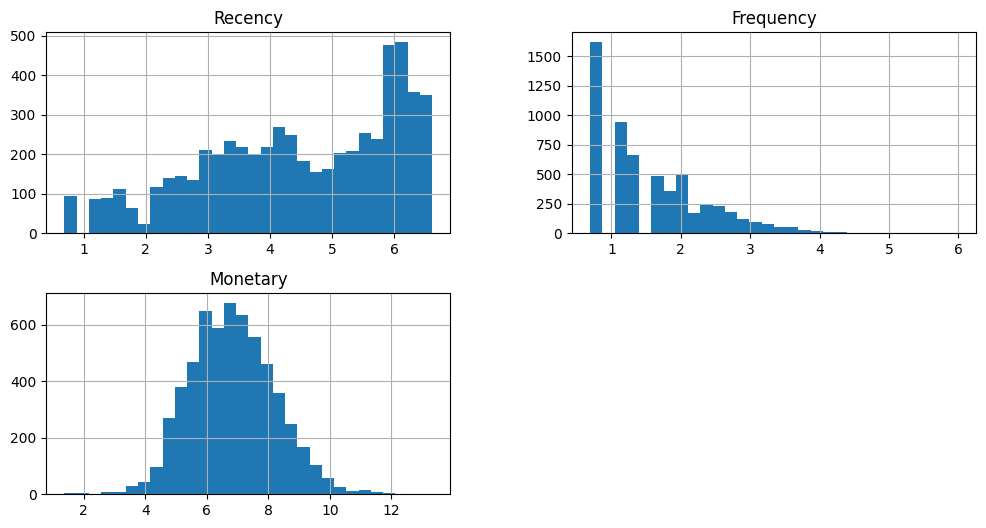

In [38]:
rfm_log[['Recency', 'Frequency', 'Monetary']].hist(
    bins=30,
    figsize=(12,6)
)

plt.show()

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [40]:
rfm.to_csv("../data/online_retail.csv/rfm.csv")

In [41]:
rfm_log.to_csv("../data/online_retail.csv/rfm_log.csv")

In [42]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

In [43]:
rfm_scaled_df.to_csv("../data/online_retail.csv/rfm_scaled.csv")

In [44]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [45]:
import hdbscan 

import matplotlib.pyplot as plt 
import seaborn as sns 



In [46]:
clusterer=hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean')

In [47]:
clusters=clusterer.fit_predict(rfm_scaled)

In [48]:
rfm['Cluster']=clusters

In [49]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,-1
12347.0,2,8,5633.32,-1
12348.0,75,5,2019.40,3
12349.0,19,4,4428.69,-1
12350.0,310,1,334.40,1


In [50]:
rfm['Cluster'].value_counts()

Cluster
 3    2281
-1    1699
 1    1025
 2     766
 0     107
Name: count, dtype: int64

In [51]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
-1,111.289582,11.697469,7214.848852
0,68.476636,1.000000,318.579720
1,472.270244,1.000000,263.836225
2,272.754569,2.000000,584.705432
3,128.896975,6.326611,2074.965566


In [52]:
from sklearn.decomposition import PCA

In [56]:
pca=PCA(n_components=2)
rfm_pca=pca.fit_transform(rfm_scaled)

In [57]:
pca_df = pd.DataFrame({
    'PC1': rfm_pca[:,0],
    'PC2': rfm_pca[:,1],
    'Cluster': clusters
})

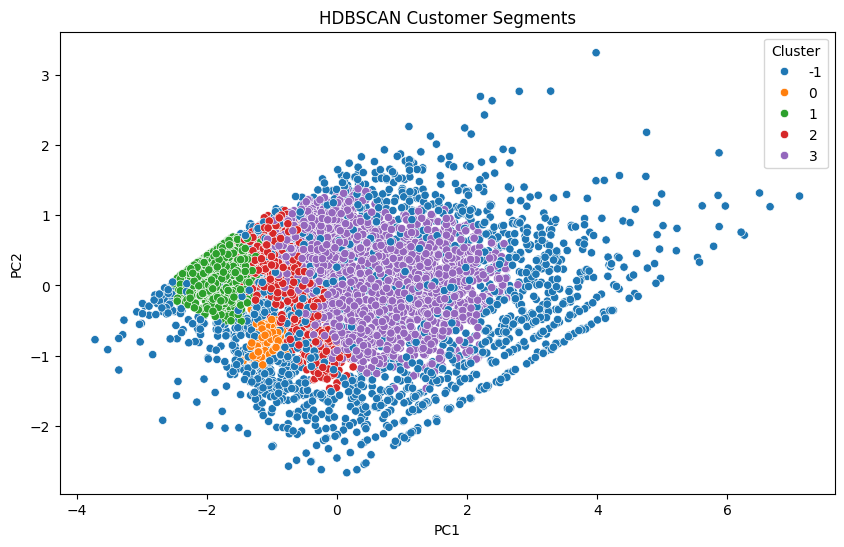

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10'
)

plt.title("HDBSCAN Customer Segments")

plt.show()

In [59]:
from sklearn.metrics import silhouette_score

In [60]:
mask = clusters != -1

In [61]:
score = silhouette_score(
    rfm_scaled[mask],
    clusters[mask]
)

print(score)

0.21523891750795912


In [62]:
cluster_labels = {
    0: 'High Value',
    1: 'Churn Risk',
    2: 'Regular Customers',
    -1: 'Outliers'
}

In [63]:
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

In [64]:
rfm.to_csv("../data/online_retail.csv/rfm_segmented.csv")

In [65]:
import joblib

joblib.dump(
    clusterer,
    "../models/hdbscan_model.pkl"
)

['../models/hdbscan_model.pkl']

In [66]:
from lifetimes.utils import summary_data_from_transaction_data 
from lifetimes import BetaGeoFitter

In [67]:
df = pd.read_csv(
    "../data/online_retail.csv/cleaned_retail.csv"
)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [68]:
summary = summary_data_from_transaction_data(
     df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='Revenue',
    observation_period_end=df['InvoiceDate'].max()

)

In [69]:
summary.head()

,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,7.0,400.0,725.0,11066.637143
12347.0,7.0,402.0,404.0,717.398571
12348.0,4.0,363.0,438.0,449.310000
12349.0,3.0,571.0,589.0,1120.056667
12350.0,0.0,0.0,310.0,0.000000


In [70]:
summary = summary[summary['frequency'] > 0]

In [71]:
bgf = BetaGeoFitter(penalizer_coef=0.01)

In [72]:
bgf.fit(
    summary['frequency'],
    summary['recency'],
    summary['T']
)

<lifetimes.BetaGeoFitter: fitted with 4189 subjects, a: 0.07, alpha: 93.74, b: 0.64, r: 1.38>

In [73]:
summary['predicted_purchases'] = bgf.predict(
    30,
    summary['frequency'],
    summary['recency'],
    summary['T']
)

In [76]:
summary[['frequency', 'predicted_purchases']].head()

,frequency,predicted_purchases
Customer ID,,
12346.0,7.0,0.176827
12347.0,7.0,0.498251
12348.0,4.0,0.289942
12349.0,3.0,0.186376
12352.0,8.0,0.567007


In [77]:
summary.sort_values(
    'predicted_purchases',
    ascending=False
).head(10)

,frequency,recency,T,monetary_value,predicted_purchases
Customer ID,,,,,
14911.0,254.0,737.0,738.0,1162.358268,9.196117
12748.0,201.0,735.0,735.0,280.490000,7.314125
15311.0,195.0,738.0,738.0,594.605846,7.071634
17841.0,192.0,736.0,737.0,366.423490,6.971264
14606.0,180.0,735.0,736.0,170.255889,6.546375
13089.0,131.0,735.0,737.0,888.318779,4.770876
14527.0,120.0,735.0,737.0,223.904250,4.374228
14156.0,120.0,729.0,738.0,2607.329750,4.362813
12971.0,98.0,721.0,724.0,162.360612,3.637332


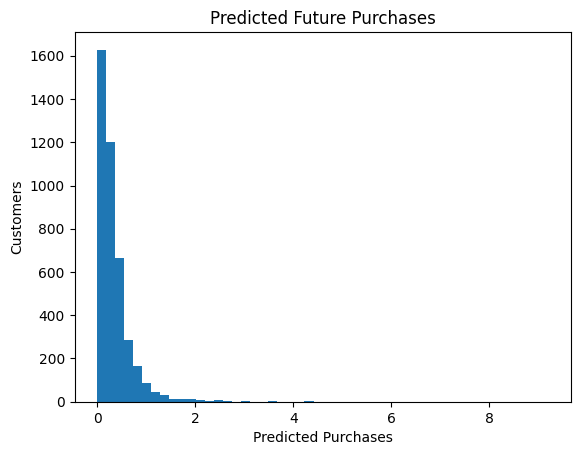

In [78]:
import matplotlib.pyplot as plt

plt.hist(
    summary['predicted_purchases'],
    bins=50
)

plt.title("Predicted Future Purchases")

plt.xlabel("Predicted Purchases")
plt.ylabel("Customers")

plt.show()

In [79]:
from lifetimes import GammaGammaFitter

In [80]:
ggf = GammaGammaFitter(
    penalizer_coef=0.01
)

In [81]:
ggf.fit(
    summary['frequency'],
    summary['monetary_value']
)

<lifetimes.GammaGammaFitter: fitted with 4189 subjects, p: 3.78, q: 0.34, v: 3.68>

In [82]:
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=6,
    freq='D',
    discount_rate=0.01
)

In [83]:
summary[['predicted_clv']].head()

,predicted_clv
Customer ID,
12346.0,11551.770168
12347.0,2103.241796
12348.0,782.309687
12349.0,1273.951062
12352.0,1125.604365


In [84]:
summary.sort_values(
    'predicted_clv',
    ascending=False
).head(10)

,frequency,recency,T,monetary_value,predicted_purchases,predicted_clv
Customer ID,,,,,,
16446.0,1.0,205.0,205.0,168469.600000,0.213626,246661.175333
18102.0,66.0,738.0,738.0,9189.930455,2.424542,128712.410713
14646.0,90.0,736.0,737.0,5809.905333,3.292781,110436.981452
17450.0,30.0,430.0,438.0,6924.523000,1.759965,70402.249758
14156.0,120.0,729.0,738.0,2607.329750,4.362813,65636.979563
14096.0,16.0,97.0,101.0,4071.434375,2.644989,61760.599700
14911.0,254.0,737.0,738.0,1162.358268,9.196117,61632.839481
12415.0,22.0,503.0,527.0,6460.528636,1.118694,41885.077577
13694.0,82.0,732.0,735.0,2365.279512,3.010868,41118.282455


In [88]:
summary.to_csv("../data/online_retail.csv/customer_clv.csv")

In [89]:
import joblib


joblib.dump(
    ggf,
    "../models/gamma_gamma_model.pkl"
)

['../models/gamma_gamma_model.pkl']